In [3]:
import os, json

os.chdir(r'C:\Users\zkx14\Desktop\testing')
print('Working directory:', os.getcwd())

with open('splits.json') as f:
    splits = json.load(f)

img_paths_all  = splits['images']
mask_paths_all = splits['masks']

print(f'Loaded {len(img_paths_all)} image-mask pairs')

Working directory: C:\Users\zkx14\Desktop\testing
Loaded 232 image-mask pairs


c:\Users\zkx14\Desktop\testing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 185 | Val: 47
Using: NVIDIA RTX 2000 Ada Generation


C:\Users\zkx14\AppData\Local\Temp\ipykernel_4212\1049440009.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\zkx14\AppData\Local\Temp\ipykernel_4212\1049440009.py:180: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\zkx14\AppData\Local\Temp\ipykernel_4212\1049440009.py:202: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/50 |  Train Loss: 0.4857 |  Val Loss: 0.4779
✓ Best model saved  (val loss: 0.4779)
Epoch 02/50 |  Train Loss: 0.4562 |  Val Loss: 0.4490
✓ Best model saved  (val loss: 0.4490)
Epoch 03/50 |  Train Loss: 0.4451 |  Val Loss: 0.4417
✓ Best model saved  (val loss: 0.4417)
Epoch 04/50 |  Train Loss: 0.4389 |  Val Loss: 0.4381
✓ Best model saved  (val loss: 0.4381)
Epoch 05/50 |  Train Loss: 0.4340 |  Val Loss: 0.4346
✓ Best model saved  (val loss: 0.4346)
Epoch 06/50 |  Train Loss: 0.4316 |  Val Loss: 0.4319
✓ Best model saved  (val loss: 0.4319)
Epoch 07/50 |  Train Loss: 0.4293 |  Val Loss: 0.4298
✓ Best model saved  (val loss: 0.4298)
Epoch 08/50 |  Train Loss: 0.4280 |  Val Loss: 0.4277
✓ Best model saved  (val loss: 0.4277)
Epoch 09/50 |  Train Loss: 0.4259 |  Val Loss: 0.4266
✓ Best model saved  (val loss: 0.4266)
Epoch 10/50 |  Train Loss: 0.4243 |  Val Loss: 0.4253
✓ Best model saved  (val loss: 0.4253)
Epoch 11/50 |  Train Loss: 0.4238 |  Val Loss: 0.4242
✓ Best model sav

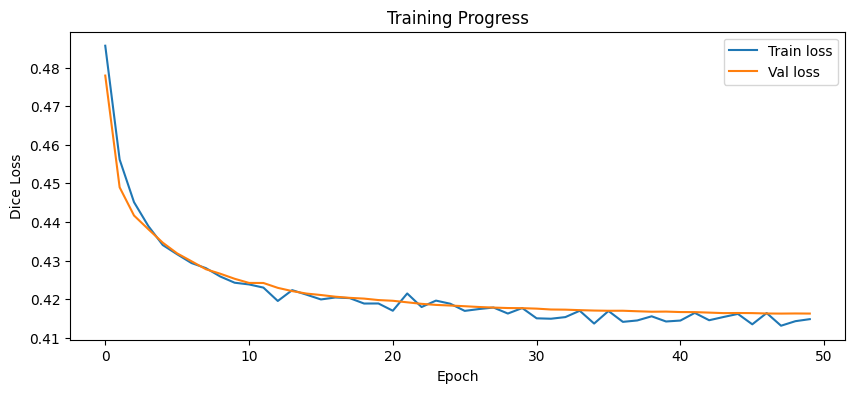


Done!  Best val loss: 0.4163 


In [ ]:
# Dental X-ray mandible segmentation training pipeline
# using U-Net with ResNet50 backbone and Dice loss optimization.
# =========================================================
# This cell trains a model to find and segment the mandible
# region in panoramic dental X-rays.
#
# What it does:
# 1. defines a custom PyTorch Dataset for image-mask pairs
# 2. adds augmentations with Albumentations
# 3. splits into train and validation sets
# 4. trains a U-Net with ResNet50 backbone
# 5. optimizes with Dice loss
# 6. validates each epoch
# 7. saves the best checkpoint
# 8. plots loss curves

# Notes:
# - uses pretrained encoder weights
# - uses mixed precision when available
# - binary mask output is mandible vs background

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Custom Dataset
# Load X-rays and masks, apply augmentations, and return tensors
class DentalDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.img_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(self.mask_paths[idx]), 0)

        # Convert grayscale mask to binary
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        # Add channel dimension to mask
        return img, mask.unsqueeze(0)

# Data augmentation & preprocessing
# Training uses augmentations to make the model more robust.
# Validation only resizes and normalizes.
train_transform = A.Compose([
    A.Resize(512, 1024),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=10,
        p=0.4
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 1024),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

# Train / Validation Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths_all,
    mask_paths_all,
    test_size=0.2,
    random_state=42
)

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# Dataset & DataLoader Creation
train_ds = DentalDataset(
    train_imgs,
    train_masks,
    train_transform
)

val_ds = DentalDataset(
    val_imgs,
    val_masks,
    val_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Model configuration
# U-Net with ResNet50 backbone pretrained on ImageNet.
# The model outputs one binary mask channel.
device = torch.device("cuda")

print(f"Using: {torch.cuda.get_device_name(0)}")

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(device)

# Training utilities
# - Dice loss for segmentation
# - Adam optimizer
# - reduce LR when validation plateaus
# - mixed precision to speed up training
scaler = torch.cuda.amp.GradScaler()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

loss_fn = smp.losses.DiceLoss(mode='binary')

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=5
)

# Training & validation
# Each epoch: train, validate, and save the best model
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(50):

    # Training
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:

        imgs, masks = imgs.to(device), masks.to(device)

        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)

        optimizer.zero_grad()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs, masks = imgs.to(device), masks.to(device)

            with torch.cuda.amp.autocast():
                preds = model(imgs)
                val_loss += loss_fn(preds, masks).item()

    # Average epoch losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1:02d}/50 | ",
        f"Train Loss: {train_loss:.4f} | ",
        f"Val Loss: {val_loss:.4f}",
    )

    # if validation improves, save this model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            'models/unet_resnet50.pth'
        )

        print(
            f"Best model saved ",
            f"(val loss: {best_val_loss:.4f})"
        )

# training curve visualization

plt.figure(figsize=(10, 4))

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')

plt.xlabel('Epoch')
plt.ylabel('Dice Loss')

plt.title('Training Progress - U-Net ResNet50')

plt.legend()

plt.show()

# summary
print(
    f"\nDone! ",
    f"Best val loss: {best_val_loss:.4f} "
 )